<a href="https://colab.research.google.com/github/RonakkudalAI/Data-Analysis/blob/main/Smote.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/Heart_attack.csv")
df

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,HvyAlcoholConsump,MentHlth,PhysHlth,Sex,Age,Education,Income
0,0,1,1,1,40.0,1,0,0,0,0,18,15,0,9,4,3
1,0,0,0,0,25.0,1,0,0,1,0,0,0,0,7,6,1
2,0,1,1,1,28.0,0,0,0,0,0,30,30,0,9,4,8
3,0,1,0,1,27.0,0,0,0,1,0,0,0,0,11,3,6
4,0,1,1,1,24.0,0,0,0,1,0,3,0,0,11,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129993,0,1,1,1,25.0,1,0,0,1,0,0,28,0,7,6,7
129994,0,0,0,1,27.0,0,0,0,0,0,0,0,0,9,6,8
129995,0,0,0,1,29.0,0,0,0,1,0,2,5,0,4,6,8
129996,0,0,0,0,21.0,0,0,0,1,0,0,5,0,4,6,8


In [5]:
df.isnull().sum()

,0
HeartDiseaseorAttack,0
HighBP,0
HighChol,0
CholCheck,0
BMI,10
Smoker,0
Stroke,0
Diabetes,0
PhysActivity,0
HvyAlcoholConsump,0


In [6]:
median_BMI = df['BMI'].median()
df['BMI'].fillna(median_BMI, inplace=True)
display(df['BMI'].isnull().sum())

/tmp/ipykernel_896/2373997674.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['BMI'].fillna(median_BMI, inplace=True)


np.int64(0)

In [7]:
#Correlation

corr = df.corr()
corr

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,HvyAlcoholConsump,MentHlth,PhysHlth,Sex,Age,Education,Income
HeartDiseaseorAttack,1.000000,0.211181,0.177354,0.042719,0.050603,0.112623,0.204792,0.182306,-0.086752,-0.027081,0.066010,0.180468,0.085814,0.218192,-0.098555,-0.139747
HighBP,0.211181,1.000000,0.297296,0.098685,0.203390,0.097619,0.128962,0.273282,-0.127653,-0.008994,0.055323,0.158598,0.047415,0.341555,-0.142350,-0.172275
HighChol,0.177354,0.297296,1.000000,0.085898,0.098521,0.089167,0.090472,0.210757,-0.078133,-0.014503,0.060490,0.120963,0.029377,0.273004,-0.069075,-0.085535
CholCheck,0.042719,0.098685,0.085898,1.000000,0.033627,-0.010890,0.024501,0.067334,0.005760,-0.022397,-0.009162,0.030483,-0.023613,0.089742,0.003524,0.017773
BMI,0.050603,0.203390,0.098521,0.033627,1.000000,0.008886,0.018452,0.210630,-0.144269,-0.048072,0.083892,0.114761,0.040440,-0.042236,-0.099994,-0.100560
Smoker,0.112623,0.097619,0.089167,-0.010890,0.008886,1.000000,0.061250,0.060999,-0.089081,0.100045,0.091215,0.117084,0.088015,0.125065,-0.166913,-0.131195
Stroke,0.204792,0.128962,0.090472,0.024501,0.018452,0.061250,1.000000,0.106055,-0.070983,-0.017658,0.077632,0.153485,0.001929,0.126549,-0.078567,-0.132716
Diabetes,0.182306,0.273282,0.210757,0.067334,0.210630,0.060999,0.106055,1.000000,-0.124264,-0.058049,0.077039,0.176664,0.026883,0.181581,-0.131712,-0.171710
PhysActivity,-0.086752,-0.127653,-0.078133,0.005760,-0.144269,-0.089081,-0.070983,-0.124264,1.000000,0.014496,-0.128760,-0.222785,0.031318,-0.093544,0.203485,0.197570
HvyAlcoholConsump,-0.027081,-0.008994,-0.014503,-0.022397,-0.048072,0.100045,-0.017658,-0.058049,0.014496,1.000000,0.022439,-0.027758,0.001887,-0.033899,0.023593,0.052876


<Axes: >

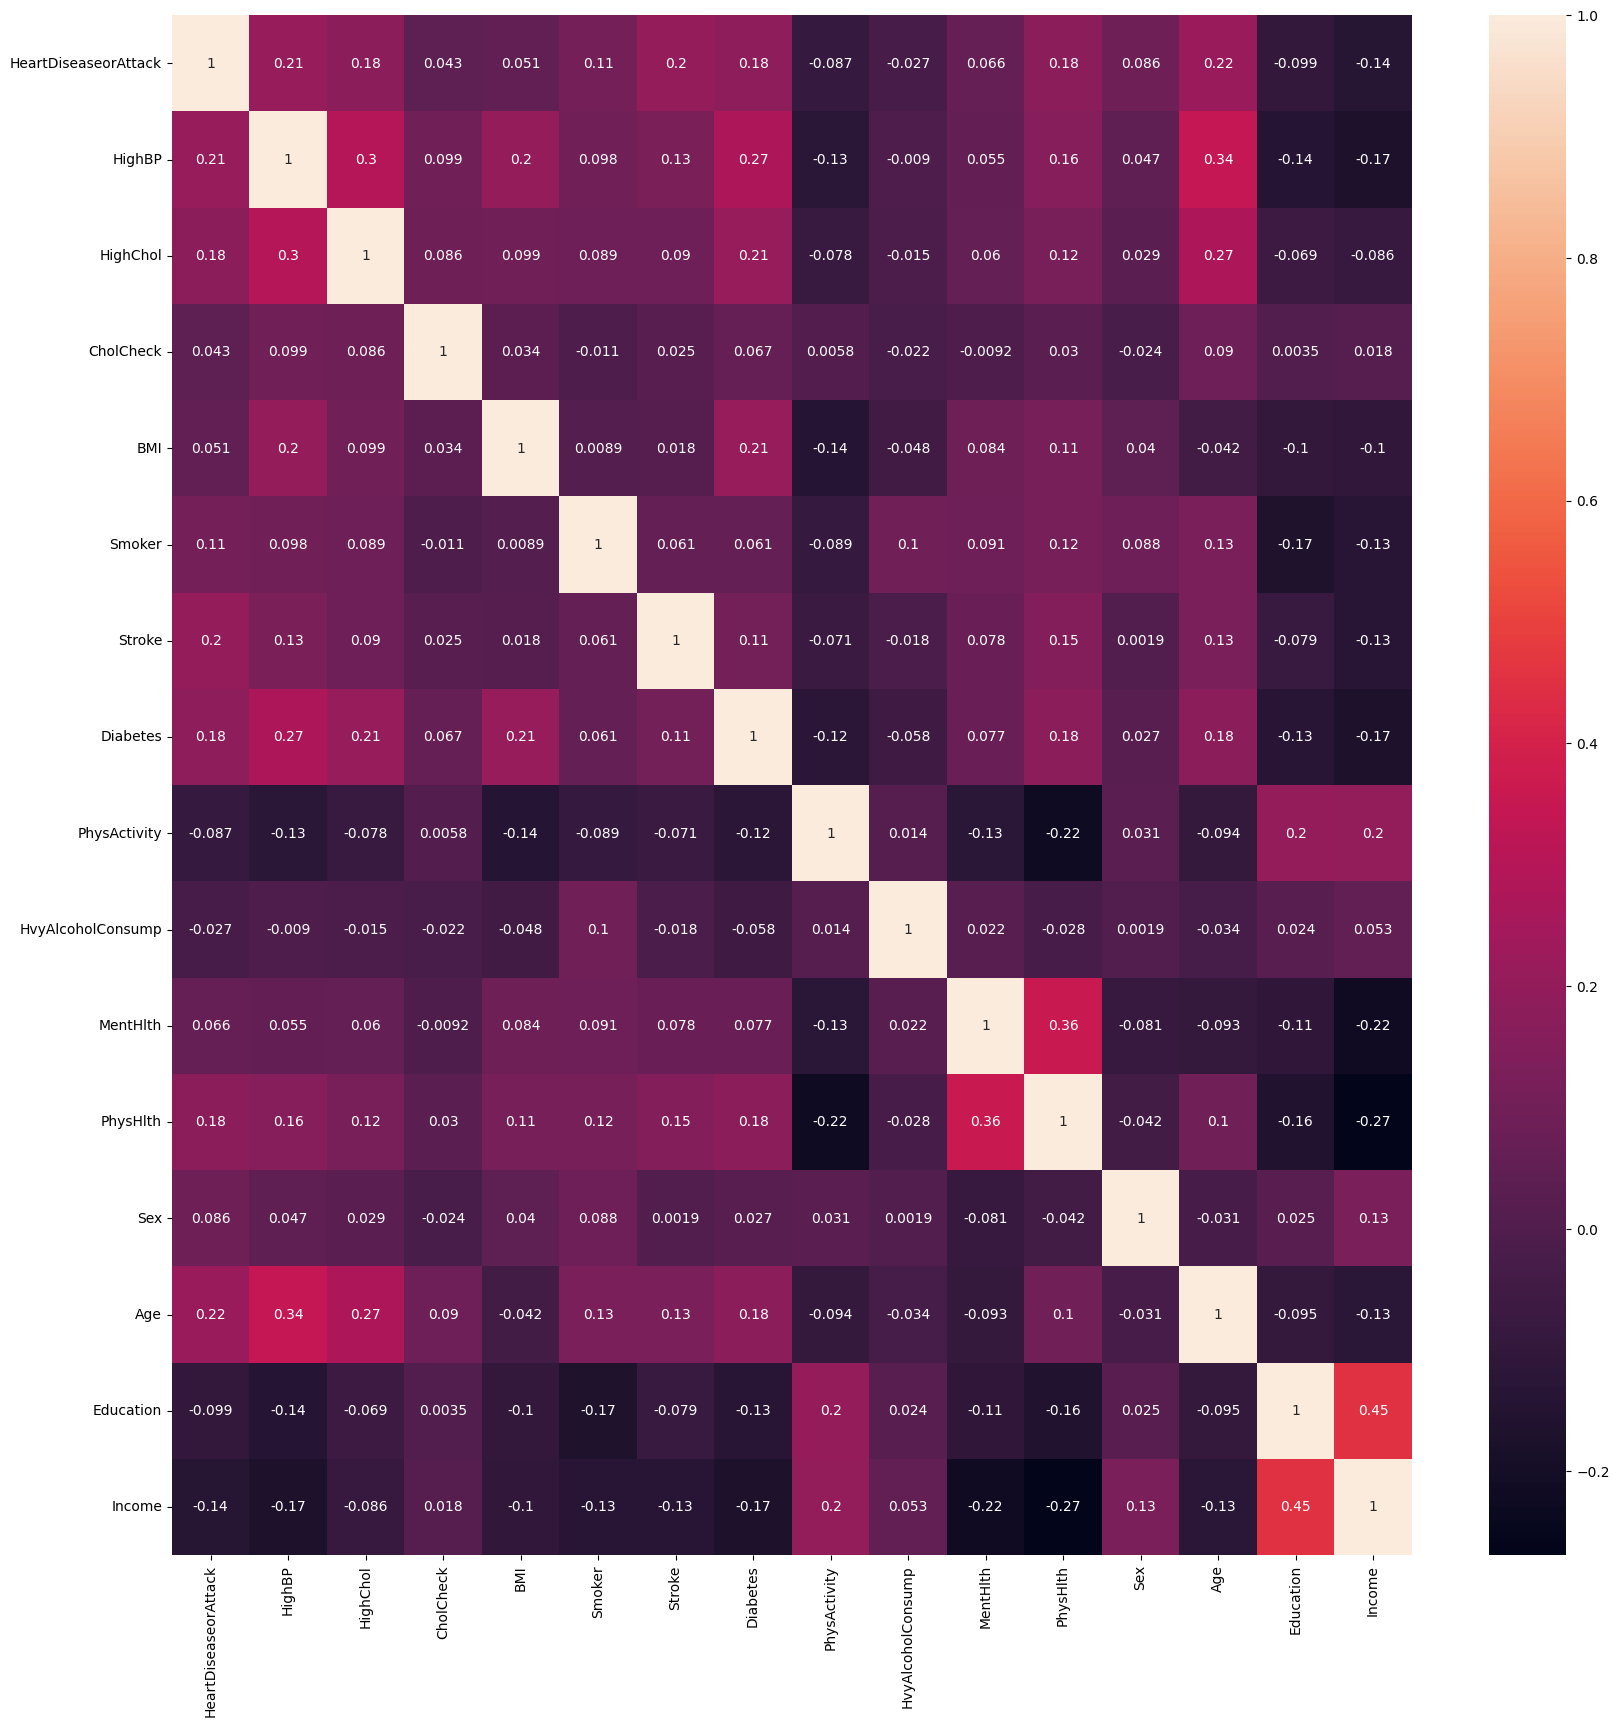

In [8]:
plt.figure(figsize=(20,20))
sns.heatmap(corr,annot=True)


In [9]:
x = df[['BMI','HighBP','Stroke','HighChol','Age','Diabetes']]
y = df['HeartDiseaseorAttack']

In [10]:
def outlier(x, y):
    x_maj = x[y == 0]
    y_maj = y[y == 0]

    x_min = x[y == 1]
    y_min = y[y == 1]

    Q1 = x_maj.quantile(0.25)
    Q3 = x_maj.quantile(0.75)
    IQR = Q3 - Q1

    df2 = ~((x_maj < (Q1 - 1.5 * IQR)) | (x_maj > (Q3 + 1.5 * IQR))).any(axis=1)

    x_clean = x_maj[df2]
    y_clean = y_maj[df2]

    x_df = pd.concat([x_clean, x_min])
    y_df = pd.concat([y_clean, y_min])

    return x_df, y_df

In [11]:
x1,y1 = outlier(x,y)


In [12]:
print(x1.shape)
print(y1.value_counts())

(108427, 6)
HeartDiseaseorAttack
0    96271
1    12156
Name: count, dtype: int64


In [13]:
#Smote
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x,y = smote.fit_resample(x1,y1)

In [14]:
print(y.value_counts())

HeartDiseaseorAttack
0    96271
1    96271
Name: count, dtype: int64


In [15]:
from sklearn.model_selection import train_test_split

In [16]:
x_train, x_test, y_train, y_test= train_test_split(x1,y1,test_size=0.2,random_state=42)

In [17]:
from sklearn.linear_model import LogisticRegression



In [18]:
LR_model = LogisticRegression()
LR_model.fit(x_train,y_train)
y_pred  = LR_model.predict(x_test)
print(y_pred)

[0 0 0 ... 0 0 0]


In [27]:
#Model Evaluation ------------->

from sklearn.metrics import confusion_matrix,classification_report



<Axes: >

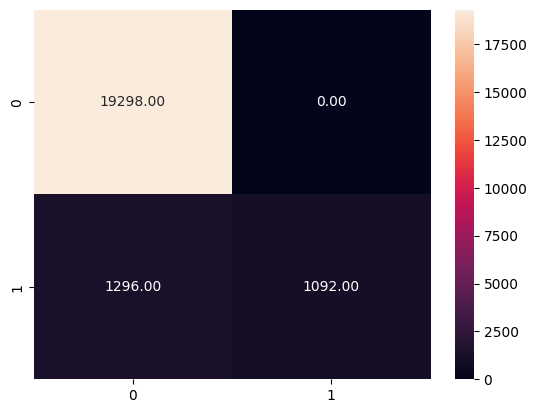

In [34]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt ="0.2f")



In [39]:
from sklearn.metrics import classification_report

cr = classification_report(y_test, y_pred, output_dict=True)
print(cr)



{'0': {'precision': 0.937069049237642, 'recall': 1.0, 'f1-score': 0.9675122831645443, 'support': 19298.0}, '1': {'precision': 1.0, 'recall': 0.457286432160804, 'f1-score': 0.6275862068965518, 'support': 2388.0}, 'accuracy': 0.9402379415290971, 'macro avg': {'precision': 0.9685345246188211, 'recall': 0.728643216080402, 'f1-score': 0.797549245030548, 'support': 21686.0}, 'weighted avg': {'precision': 0.9439988246881865, 'recall': 0.9402379415290971, 'f1-score': 0.930080600506241, 'support': 21686.0}}


In [40]:
baseline = [0] * len(df)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, baseline[:len(y_test)])
print(accuracy)

0.8898828737434289
